# Data Analysis ~ Obj 02

In [1]:
import pandas as pd
import numpy  as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

## X2.0 ~ Baseline

passage_time: 10; interval: 3; window: 3

In [2]:
x20_folder_path = '../infra/reports/batch_baseline'

### Predict

In [3]:
from pandas import json_normalize
import json

with open(f'{x20_folder_path}/metrics.json') as f:
    x20_data = json.load(f)

load_model_duration = datetime.fromisoformat(x20_data['load_model_final']) - datetime.fromisoformat(x20_data['load_model_start'])
    
rows = []
for animal, v1 in x20_data['animals'].items():
    row = {
        'pid': x20_data['pid'],
        'load_model_start': datetime.fromisoformat(x20_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x20_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],
    }
    
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx20_metrics_v0 = pd.DataFrame.from_dict(rows)
dx20_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,1,2026-04-17 16:34:48.498905,2026-04-17 16:34:58.398448,2026-04-17 16:35:00.646093,11,3,2026-04-17 16:34:59.360526,2026-04-17 16:35:00.646012
1,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,2,2026-04-17 16:35:03.646204,2026-04-17 16:35:13.411903,2026-04-17 16:35:15.892372,11,4,2026-04-17 16:35:14.381794,2026-04-17 16:35:15.892298
2,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,3,2026-04-17 16:35:18.894002,2026-04-17 16:35:28.642804,2026-04-17 16:35:31.124555,11,4,2026-04-17 16:35:29.619902,2026-04-17 16:35:31.124492
3,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,4,2026-04-17 16:35:34.126128,2026-04-17 16:35:43.882998,2026-04-17 16:35:46.365044,11,4,2026-04-17 16:35:44.859654,2026-04-17 16:35:46.364982
4,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,5,2026-04-17 16:35:49.366634,2026-04-17 16:35:59.101561,2026-04-17 16:36:01.584840,11,4,2026-04-17 16:36:00.081610,2026-04-17 16:36:01.584772


In [4]:
dx20_metrics_v0['by_animal_lead_time'] = dx20_metrics_v0['display_time'] - dx20_metrics_v0['first_image_capture_time']
dx20_metrics_v0['by_animal_processing_delay'] = dx20_metrics_v0['weight_prediction_final'] - dx20_metrics_v0['weight_prediction_start']
dx20_metrics_v0['by_animal_latency'] = dx20_metrics_v0['display_time'] - dx20_metrics_v0['last_image_capture_time']

dx20_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,1,2026-04-17 16:34:48.498905,2026-04-17 16:34:58.398448,2026-04-17 16:35:00.646093,11,3,2026-04-17 16:34:59.360526,2026-04-17 16:35:00.646012,0 days 00:00:12.147188,0 days 00:00:01.285486,0 days 00:00:02.247645
1,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,2,2026-04-17 16:35:03.646204,2026-04-17 16:35:13.411903,2026-04-17 16:35:15.892372,11,4,2026-04-17 16:35:14.381794,2026-04-17 16:35:15.892298,0 days 00:00:12.246168,0 days 00:00:01.510504,0 days 00:00:02.480469
2,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,3,2026-04-17 16:35:18.894002,2026-04-17 16:35:28.642804,2026-04-17 16:35:31.124555,11,4,2026-04-17 16:35:29.619902,2026-04-17 16:35:31.124492,0 days 00:00:12.230553,0 days 00:00:01.504590,0 days 00:00:02.481751
3,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,4,2026-04-17 16:35:34.126128,2026-04-17 16:35:43.882998,2026-04-17 16:35:46.365044,11,4,2026-04-17 16:35:44.859654,2026-04-17 16:35:46.364982,0 days 00:00:12.238916,0 days 00:00:01.505328,0 days 00:00:02.482046
4,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,5,2026-04-17 16:35:49.366634,2026-04-17 16:35:59.101561,2026-04-17 16:36:01.584840,11,4,2026-04-17 16:36:00.081610,2026-04-17 16:36:01.584772,0 days 00:00:12.218206,0 days 00:00:01.503162,0 days 00:00:02.483279


In [5]:
collect_lead_time = dx20_metrics_v0['display_time'].max() - dx20_metrics_v0['first_image_capture_time'].min()
qtt = len(dx20_metrics_v0['animal'].unique())

dx20_metrics_v0['collect_lead_time'] = collect_lead_time
dx20_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx20_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,1,2026-04-17 16:34:48.498905,2026-04-17 16:34:58.398448,2026-04-17 16:35:00.646093,11,3,2026-04-17 16:34:59.360526,2026-04-17 16:35:00.646012,0 days 00:00:12.147188,0 days 00:00:01.285486,0 days 00:00:02.247645,0 days 00:25:16.521960,237.385287
1,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,2,2026-04-17 16:35:03.646204,2026-04-17 16:35:13.411903,2026-04-17 16:35:15.892372,11,4,2026-04-17 16:35:14.381794,2026-04-17 16:35:15.892298,0 days 00:00:12.246168,0 days 00:00:01.510504,0 days 00:00:02.480469,0 days 00:25:16.521960,237.385287
2,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,3,2026-04-17 16:35:18.894002,2026-04-17 16:35:28.642804,2026-04-17 16:35:31.124555,11,4,2026-04-17 16:35:29.619902,2026-04-17 16:35:31.124492,0 days 00:00:12.230553,0 days 00:00:01.504590,0 days 00:00:02.481751,0 days 00:25:16.521960,237.385287
3,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,4,2026-04-17 16:35:34.126128,2026-04-17 16:35:43.882998,2026-04-17 16:35:46.365044,11,4,2026-04-17 16:35:44.859654,2026-04-17 16:35:46.364982,0 days 00:00:12.238916,0 days 00:00:01.505328,0 days 00:00:02.482046,0 days 00:25:16.521960,237.385287
4,batch_2026-04-17T16:34:41.531317,2026-04-17 16:34:41.531807,2026-04-17 16:34:48.498785,0 days 00:00:06.966978,5,2026-04-17 16:35:49.366634,2026-04-17 16:35:59.101561,2026-04-17 16:36:01.584840,11,4,2026-04-17 16:36:00.081610,2026-04-17 16:36:01.584772,0 days 00:00:12.218206,0 days 00:00:01.503162,0 days 00:00:02.483279,0 days 00:25:16.521960,237.385287


In [6]:
dx20_metrics_v0.describe()

,load_model_dur,total_of_images,suitable_images,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,100,100.0,100.00,100,100,100,100,1.000000e+02
mean,0 days 00:00:06.966978,11.0,3.99,0 days 00:00:12.193669630,0 days 00:00:01.504148800,0 days 00:00:02.469420410,0 days 00:25:16.521960,2.373853e+02
std,0 days 00:00:00,0.0,0.10,0 days 00:00:00.019387663,0 days 00:00:00.022677945,0 days 00:00:00.023838794,0 days 00:00:00,2.856489e-13
min,0 days 00:00:06.966978,11.0,3.00,0 days 00:00:12.147188,0 days 00:00:01.285486,0 days 00:00:02.247645,0 days 00:25:16.521960,2.373853e+02
25%,0 days 00:00:06.966978,11.0,4.00,0 days 00:00:12.180600750,0 days 00:00:01.502726250,0 days 00:00:02.464826,0 days 00:25:16.521960,2.373853e+02
50%,0 days 00:00:06.966978,11.0,4.00,0 days 00:00:12.189137500,0 days 00:00:01.504735,0 days 00:00:02.469943,0 days 00:25:16.521960,2.373853e+02
75%,0 days 00:00:06.966978,11.0,4.00,0 days 00:00:12.206204,0 days 00:00:01.509799750,0 days 00:00:02.479028250,0 days 00:25:16.521960,2.373853e+02
max,0 days 00:00:06.966978,11.0,4.00,0 days 00:00:12.246168,0 days 00:00:01.519931,0 days 00:00:02.493747,0 days 00:25:16.521960,2.373853e+02


In [7]:
dx20_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:02:30.414880')

In [8]:
total_of_imgs = dx20_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx20_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 1100 - Time: 0 days 00:25:16.521960 => FPS:0.7253439310565605


### CPU

In [9]:
dx20_cpu = pd.read_csv(f'{x20_folder_path}/cpu.csv')

dx20_cpu['timestamp'] = dx20_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx20_cpu['cpu_mean']  = dx20_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx20_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-17 16:34:42.534646,2.0,2.0,76.2,22.8,25.750
1,2026-04-17 16:34:43.560121,10.0,18.2,48.0,46.5,30.675
2,2026-04-17 16:34:44.596696,1.0,0.0,0.0,99.0,25.000
3,2026-04-17 16:34:45.597138,1.0,1.0,1.0,48.5,12.875
4,2026-04-17 16:34:46.597574,0.0,0.0,0.0,3.0,0.750


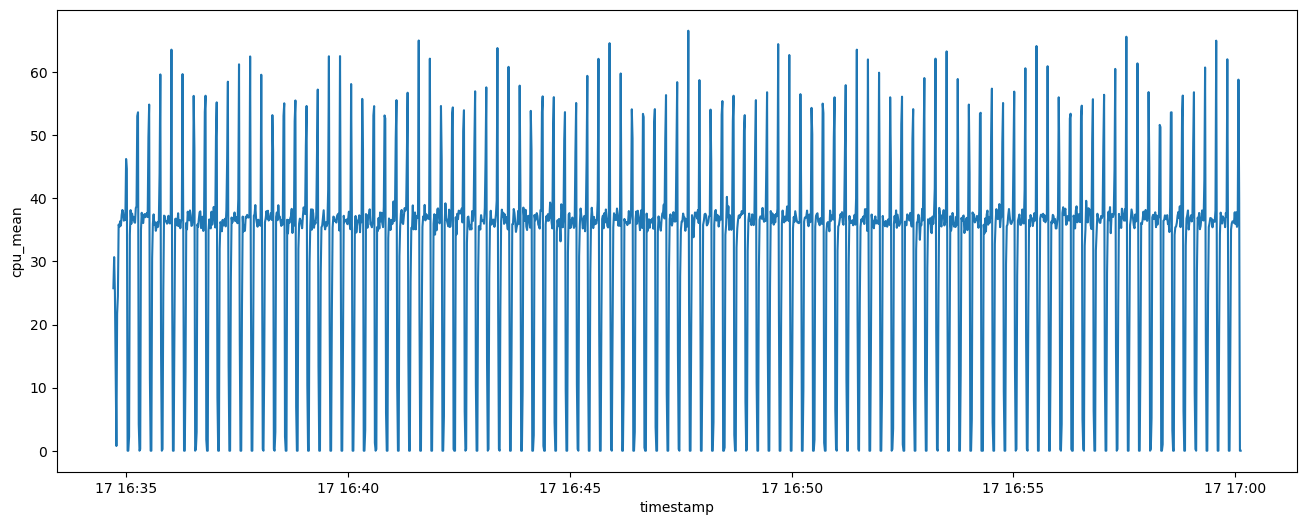

In [10]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx20_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

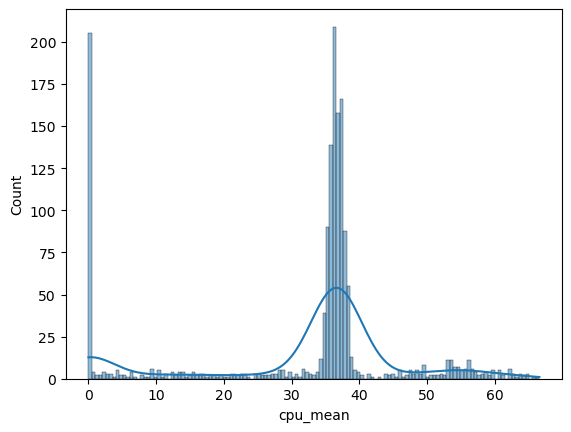

In [11]:
sns.histplot(data=dx20_cpu, x="cpu_mean", kde=True)
plt.show()

In [12]:
dx20_cpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,1519.000000,1519.000000,1519.000000,1519.000000,1519.000000
mean,29.779065,33.711389,33.259908,29.670770,31.605283
std,20.731694,22.387042,22.324588,20.473336,15.597496
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.300000,18.200000,18.000000,17.500000,34.487500
50%,25.000000,33.000000,31.000000,25.500000,36.350000
75%,44.400000,51.000000,50.500000,43.900000,37.425000
max,91.000000,92.800000,94.800000,99.000000,66.550000


### RAM

In [13]:
dx20_ram = pd.read_csv(f'{x20_folder_path}/mem.csv')
dx20_ram['timestamp'] = dx20_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx20_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-17 16:34:41.532007,17006837760,16469524480,537313280,3.2,15861399552,734216192,195411968,40009728,686686208
1,2026-04-17 16:34:42.534420,17006837760,16431136768,575700992,3.4,15820341248,769933312,196427776,40009728,689242112
2,2026-04-17 16:34:43.570458,17006837760,16323985408,682852352,4.0,15713189888,838500352,196427776,40009728,689242112
3,2026-04-17 16:34:44.575800,17006837760,16286515200,720322560,4.2,15675588608,877592576,196427776,40009728,689373184
4,2026-04-17 16:34:45.576143,17006837760,16125476864,881360896,5.2,15464497152,1008222208,246480896,40009728,739459072


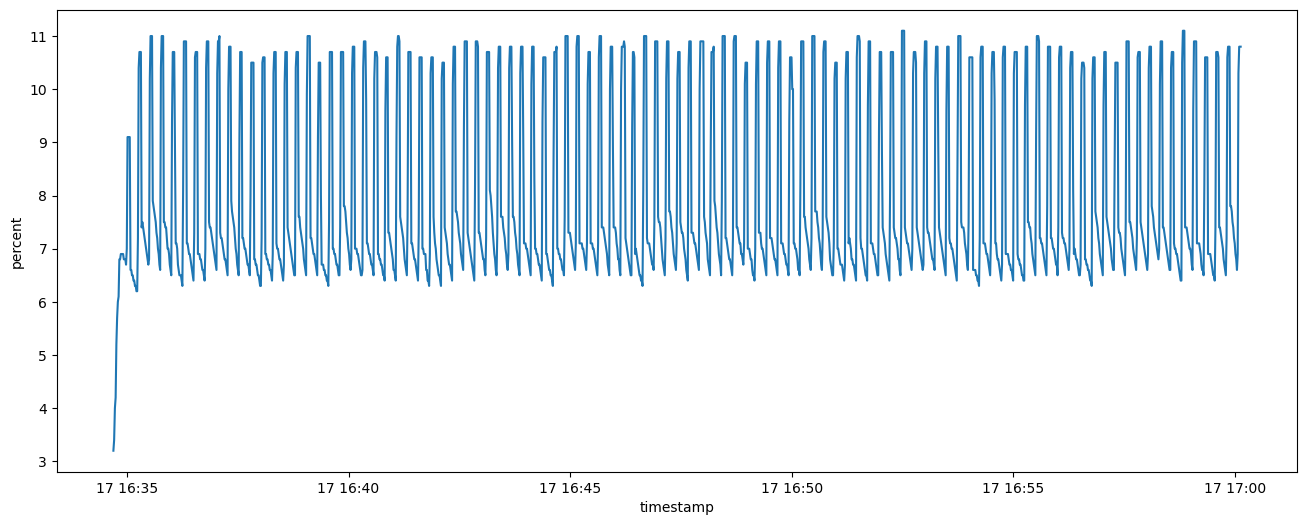

In [14]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx20_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

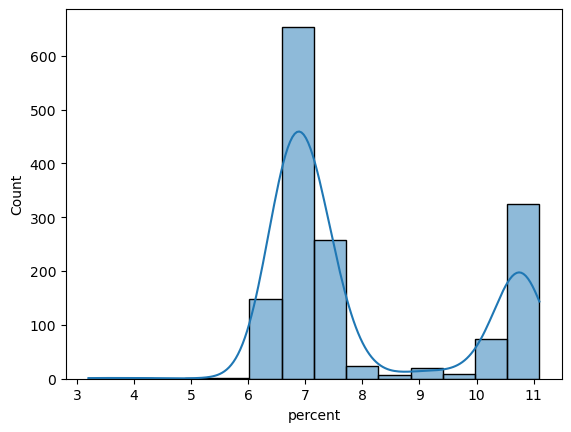

In [15]:
sns.histplot(data=dx20_ram, x="percent", kde=True)
plt.show()

In [16]:
dx20_ram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,1.522000e+03,1.522000e+03,1.522000e+03,1522.000000,1.522000e+03,1.522000e+03,1.522000e+03,1.522000e+03,1.522000e+03
mean,1.700684e+10,1.565262e+10,1.354222e+09,7.964192,1.487978e+10,1.409544e+09,3.544031e+08,4.027836e+07,8.511137e+08
std,0.000000e+00,2.909347e+08,2.909347e+08,1.711603,2.922846e+08,2.987134e+08,8.598059e+06,2.297243e+05,8.837901e+06
min,1.700684e+10,1.512151e+10,5.373133e+08,3.200000,1.434788e+10,7.342162e+08,1.954120e+08,4.000973e+07,6.866862e+08
25%,1.700684e+10,1.527463e+10,1.148158e+09,6.800000,1.450102e+10,1.216217e+09,3.546644e+08,4.004250e+07,8.515584e+08
50%,1.700684e+10,1.579889e+10,1.207951e+09,7.100000,1.502554e+10,1.218904e+09,3.551068e+08,4.048486e+07,8.517059e+08
75%,1.700684e+10,1.585868e+10,1.732211e+09,10.200000,1.508523e+10,1.830240e+09,3.551232e+08,4.050125e+07,8.517059e+08
max,1.700684e+10,1.646952e+10,1.885323e+09,11.100000,1.586140e+10,1.915191e+09,3.551396e+08,4.051763e+07,8.517059e+08


### Power

In [17]:
dx20_power = pd.read_csv(f'{x20_folder_path}/power.csv')
dx20_power['timestamp'] = dx20_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx20_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-17T16:34:31.155259,0.0,5.1096,0.55546,2.8328,2026-04-17 16:34:31.155259
1,2026-04-17T16:34:32.122710,1.0,5.1096,0.58730,2.9952,2026-04-17 16:34:32.122710
2,2026-04-17T16:34:33.139966,2.0,5.1094,0.77582,3.9566,2026-04-17 16:34:33.139966
3,2026-04-17T16:34:34.159820,3.0,5.1092,0.77238,3.9391,2026-04-17 16:34:34.159820
4,2026-04-17T16:34:35.131664,4.0,5.1089,0.77649,3.9600,2026-04-17 16:34:35.131664


In [18]:
dx20_power = dx20_power.sort_values('timestamp')

# Time difference in hours
dx20_power['dt_hours'] = dx20_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx20_power['energy_Wh'] = dx20_power['Power[W]'] * dx20_power['dt_hours']

# Total energy
total_energy_Wh = dx20_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 2.3209750335498054
Total energy (kWh): 0.0023209750335498056


In [19]:
dx20_power.describe()

,Time[S],Volt[V],Current[A],Power[W],dt_hours,energy_Wh
count,1540.000000,1540.000000,1540.000000,1540.000000,1539.000000,1539.000000
mean,769.584416,5.107147,1.063958,5.427610,0.000278,0.001508
std,444.761783,0.004575,0.183448,0.936051,0.000006,0.000260
min,0.000000,5.086400,0.555460,2.832800,0.000269,0.000805
25%,384.750000,5.105300,1.003973,5.120425,0.000271,0.001404
50%,769.600000,5.107900,1.081880,5.522850,0.000283,0.001537
75%,1154.350000,5.109400,1.165470,5.946800,0.000283,0.001665
max,1539.200000,5.123300,1.802780,9.212200,0.000285,0.002569


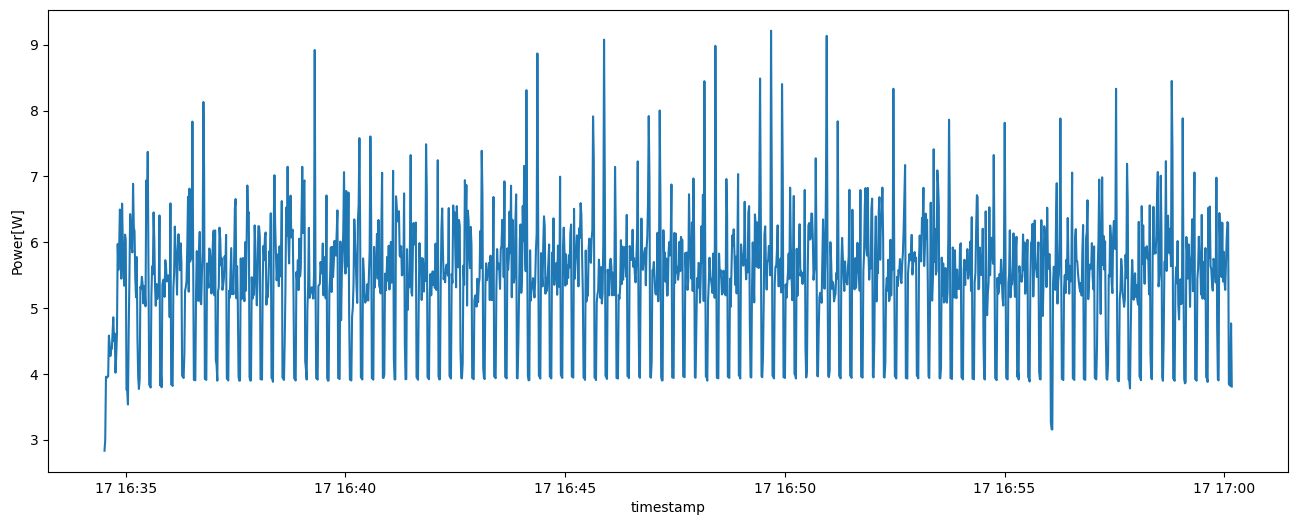

In [20]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx20_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## X2.1

passage_time: 5; interval: 3; window: 3

In [78]:
x21_folder_path = '../infra/reports/batch_x21'

### Predict

In [79]:
from pandas import json_normalize
import json

with open(f'{x21_folder_path}/metrics.json') as f:
    x21_data = json.load(f)

load_model_duration = datetime.fromisoformat(x21_data['load_model_final']) - datetime.fromisoformat(x21_data['load_model_start'])
    
rows = []
for animal, v1 in x21_data['animals'].items():
    row = {
        'pid': x21_data['pid'],
        'load_model_start': datetime.fromisoformat(x21_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x21_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],    
    }
    
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx21_metrics_v0 = pd.DataFrame.from_dict(rows)
dx21_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,1,2026-04-17 17:05:57.231821,2026-04-17 17:06:01.410884,2026-04-17 17:06:03.742907,5,3,2026-04-17 17:06:02.419459,2026-04-17 17:06:03.742819
1,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2,2026-04-17 17:06:06.743041,2026-04-17 17:06:10.796294,2026-04-17 17:06:13.081174,5,3,2026-04-17 17:06:11.784023,2026-04-17 17:06:13.081105
2,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,3,2026-04-17 17:06:16.082067,2026-04-17 17:06:20.091644,2026-04-17 17:06:22.441256,5,3,2026-04-17 17:06:21.102229,2026-04-17 17:06:22.441184
3,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,4,2026-04-17 17:06:25.442878,2026-04-17 17:06:29.477876,2026-04-17 17:06:31.790001,5,3,2026-04-17 17:06:30.485137,2026-04-17 17:06:31.789921
4,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,5,2026-04-17 17:06:34.791963,2026-04-17 17:06:38.816524,2026-04-17 17:06:41.118891,5,3,2026-04-17 17:06:39.809684,2026-04-17 17:06:41.118814


In [80]:
dx21_metrics_v0['by_animal_lead_time'] = dx21_metrics_v0['display_time'] - dx21_metrics_v0['first_image_capture_time']
dx21_metrics_v0['by_animal_processing_delay'] = dx21_metrics_v0['weight_prediction_final'] - dx21_metrics_v0['weight_prediction_start']
dx21_metrics_v0['by_animal_latency'] = dx21_metrics_v0['display_time'] - dx21_metrics_v0['last_image_capture_time']

dx21_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,1,2026-04-17 17:05:57.231821,2026-04-17 17:06:01.410884,2026-04-17 17:06:03.742907,5,3,2026-04-17 17:06:02.419459,2026-04-17 17:06:03.742819,0 days 00:00:06.511086,0 days 00:00:01.323360,0 days 00:00:02.332023
1,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2,2026-04-17 17:06:06.743041,2026-04-17 17:06:10.796294,2026-04-17 17:06:13.081174,5,3,2026-04-17 17:06:11.784023,2026-04-17 17:06:13.081105,0 days 00:00:06.338133,0 days 00:00:01.297082,0 days 00:00:02.284880
2,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,3,2026-04-17 17:06:16.082067,2026-04-17 17:06:20.091644,2026-04-17 17:06:22.441256,5,3,2026-04-17 17:06:21.102229,2026-04-17 17:06:22.441184,0 days 00:00:06.359189,0 days 00:00:01.338955,0 days 00:00:02.349612
3,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,4,2026-04-17 17:06:25.442878,2026-04-17 17:06:29.477876,2026-04-17 17:06:31.790001,5,3,2026-04-17 17:06:30.485137,2026-04-17 17:06:31.789921,0 days 00:00:06.347123,0 days 00:00:01.304784,0 days 00:00:02.312125
4,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,5,2026-04-17 17:06:34.791963,2026-04-17 17:06:38.816524,2026-04-17 17:06:41.118891,5,3,2026-04-17 17:06:39.809684,2026-04-17 17:06:41.118814,0 days 00:00:06.326928,0 days 00:00:01.309130,0 days 00:00:02.302367


In [81]:
collect_lead_time = dx21_metrics_v0['display_time'].max() - dx21_metrics_v0['first_image_capture_time'].min()
qtt = len(dx21_metrics_v0['animal'].unique())

dx21_metrics_v0['collect_lead_time'] = collect_lead_time
dx21_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx21_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,1,2026-04-17 17:05:57.231821,2026-04-17 17:06:01.410884,2026-04-17 17:06:03.742907,5,3,2026-04-17 17:06:02.419459,2026-04-17 17:06:03.742819,0 days 00:00:06.511086,0 days 00:00:01.323360,0 days 00:00:02.332023,0 days 00:15:39.570844,383.153652
1,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,2,2026-04-17 17:06:06.743041,2026-04-17 17:06:10.796294,2026-04-17 17:06:13.081174,5,3,2026-04-17 17:06:11.784023,2026-04-17 17:06:13.081105,0 days 00:00:06.338133,0 days 00:00:01.297082,0 days 00:00:02.284880,0 days 00:15:39.570844,383.153652
2,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,3,2026-04-17 17:06:16.082067,2026-04-17 17:06:20.091644,2026-04-17 17:06:22.441256,5,3,2026-04-17 17:06:21.102229,2026-04-17 17:06:22.441184,0 days 00:00:06.359189,0 days 00:00:01.338955,0 days 00:00:02.349612,0 days 00:15:39.570844,383.153652
3,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,4,2026-04-17 17:06:25.442878,2026-04-17 17:06:29.477876,2026-04-17 17:06:31.790001,5,3,2026-04-17 17:06:30.485137,2026-04-17 17:06:31.789921,0 days 00:00:06.347123,0 days 00:00:01.304784,0 days 00:00:02.312125,0 days 00:15:39.570844,383.153652
4,batch_2026-04-17T17:05:50.203887,2026-04-17 17:05:50.204717,2026-04-17 17:05:57.231726,0 days 00:00:07.027009,5,2026-04-17 17:06:34.791963,2026-04-17 17:06:38.816524,2026-04-17 17:06:41.118891,5,3,2026-04-17 17:06:39.809684,2026-04-17 17:06:41.118814,0 days 00:00:06.326928,0 days 00:00:01.309130,0 days 00:00:02.302367,0 days 00:15:39.570844,383.153652


In [82]:
dx21_metrics_v0.describe()

,load_model_dur,total_of_images,suitable_images,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,100,100.000000,100.000000,100,100,100,100,1.000000e+02
mean,0 days 00:00:07.027009,5.050000,3.030000,0 days 00:00:06.424034540,0 days 00:00:01.325684200,0 days 00:00:02.326210720,0 days 00:15:39.570844,3.831537e+02
std,0 days 00:00:00,0.219043,0.171447,0 days 00:00:00.237602985,0 days 00:00:00.037659547,0 days 00:00:00.040480679,0 days 00:00:00,1.142596e-13
min,0 days 00:00:07.027009,5.000000,3.000000,0 days 00:00:06.308333,0 days 00:00:01.295961,0 days 00:00:02.274947,0 days 00:15:39.570844,3.831537e+02
25%,0 days 00:00:07.027009,5.000000,3.000000,0 days 00:00:06.352670,0 days 00:00:01.312570250,0 days 00:00:02.311899500,0 days 00:15:39.570844,3.831537e+02
50%,0 days 00:00:07.027009,5.000000,3.000000,0 days 00:00:06.375167500,0 days 00:00:01.319465,0 days 00:00:02.320001500,0 days 00:15:39.570844,3.831537e+02
75%,0 days 00:00:07.027009,5.000000,3.000000,0 days 00:00:06.388513500,0 days 00:00:01.328601500,0 days 00:00:02.332950500,0 days 00:15:39.570844,3.831537e+02
max,0 days 00:00:07.027009,6.000000,4.000000,0 days 00:00:07.541387,0 days 00:00:01.540708,0 days 00:00:02.542671,0 days 00:15:39.570844,3.831537e+02


In [83]:
dx21_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:02:12.568420')

In [27]:
total_of_imgs = dx21_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx21_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 505 - Time: 0 days 00:15:39.570844 => FPS:0.5374794282143561


### CPU

In [28]:
dx21_cpu = pd.read_csv(f'{x21_folder_path}/cpu.csv')

dx21_cpu['timestamp'] = dx21_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx21_cpu['cpu_mean']  = dx21_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx21_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-17 17:05:51.205827,2.0,2.0,95.0,2.0,25.250
1,2026-04-17 17:05:52.236993,34.7,15.8,28.4,46.6,31.375
2,2026-04-17 17:05:53.403491,100.0,0.9,0.9,1.7,25.875
3,2026-04-17 17:05:54.404129,35.0,1.0,1.0,0.0,9.250
4,2026-04-17 17:05:55.404549,4.0,0.0,0.0,1.0,1.250


In [29]:
dx21_cpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,946.000000,946.000000,946.000000,946.000000,946.000000
mean,27.042178,28.093129,28.242495,24.538161,26.978990
std,23.262456,23.723330,23.637107,20.649589,17.629036
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,3.000000,4.000000,5.000000,5.868750
50%,21.200000,23.800000,23.600000,20.000000,35.400000
75%,43.900000,45.750000,45.400000,39.200000,37.075000
max,100.000000,93.800000,95.000000,92.900000,61.275000


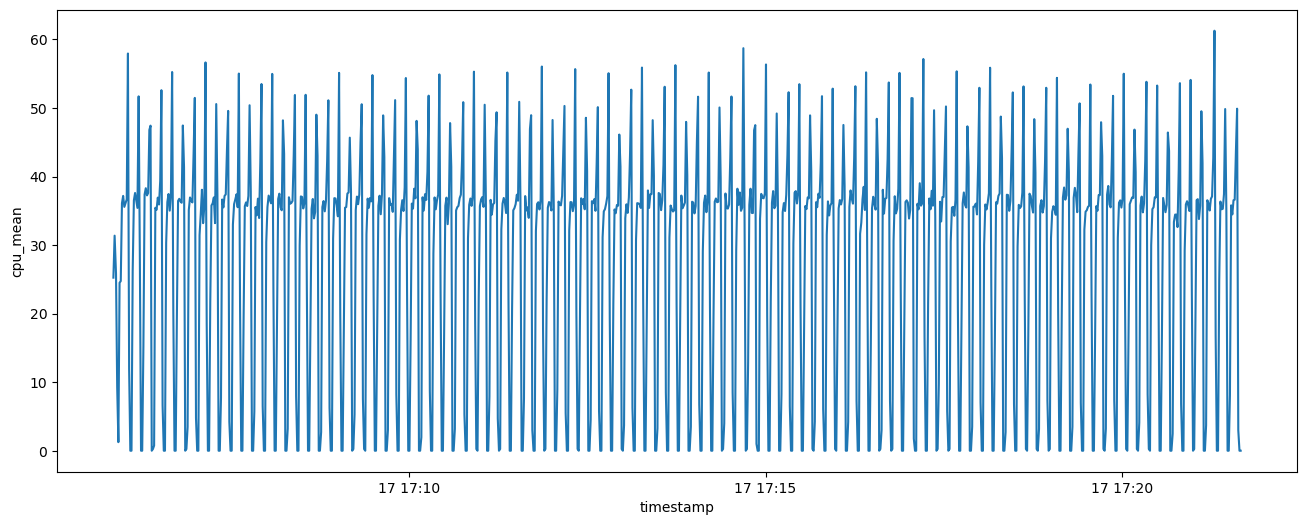

In [30]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx21_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

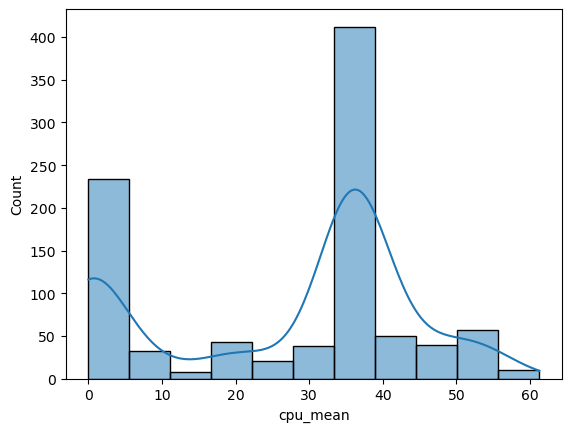

In [31]:
sns.histplot(data=dx21_cpu, x="cpu_mean", kde=True)
plt.show()

### RAM

In [32]:
dx21_ram = pd.read_csv(f'{x21_folder_path}/mem.csv')
dx21_ram['timestamp'] = dx21_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx21_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-17 17:05:50.205030,17002643456,16456679424,545964032,3.2,15874048000,720666624,184582144,38502400,661913600
1,2026-04-17 17:05:51.205898,17002643456,16418570240,584073216,3.4,15833497600,756088832,185384960,38502400,664436736
2,2026-04-17 17:05:52.221525,17002643456,16327884800,674758656,4.0,15742812160,825163776,185384960,38502400,664436736
3,2026-04-17 17:05:53.221838,17002643456,16275423232,727220224,4.3,15690219520,859160576,185384960,38502400,664567808
4,2026-04-17 17:05:54.222319,17002643456,16103407616,899235840,5.3,15471001600,991674368,232570880,38502400,712048640


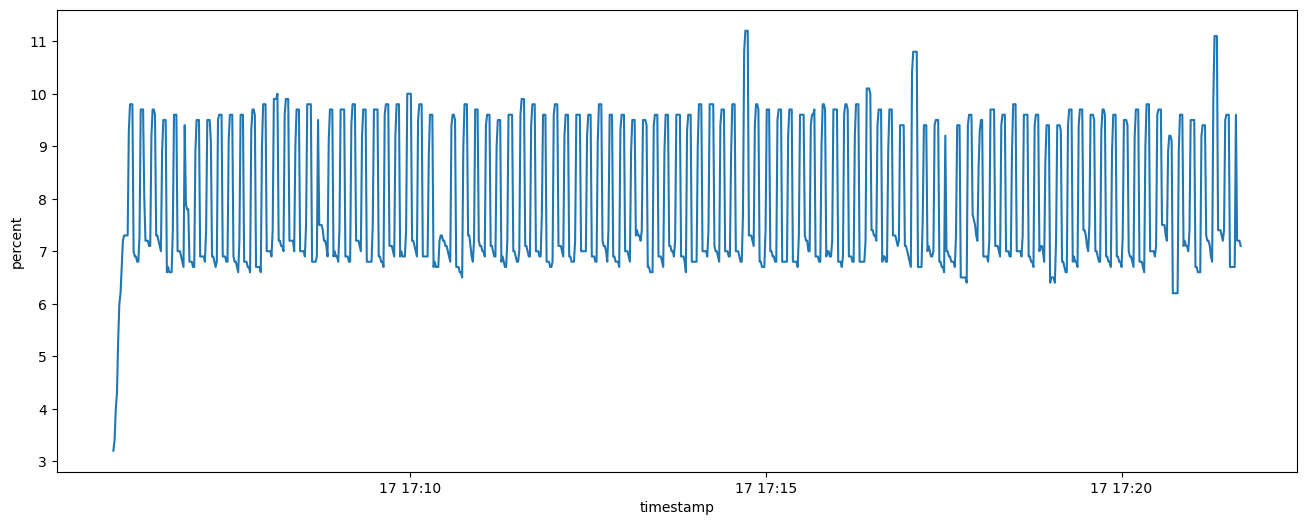

In [33]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx21_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

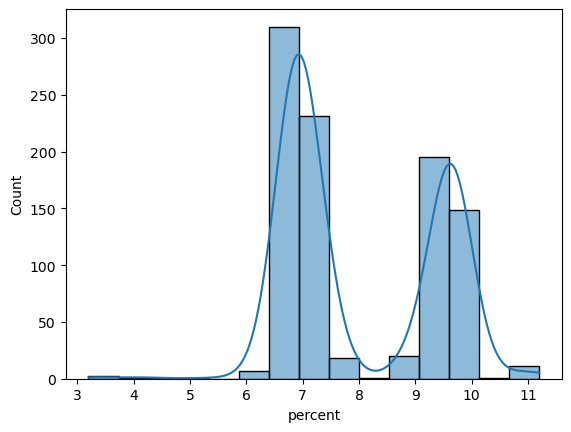

In [34]:
sns.histplot(data=dx21_ram, x="percent", kde=True)
plt.show()

In [35]:
dx21_ram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,9.480000e+02,9.480000e+02,9.480000e+02,948.000000,9.480000e+02,9.480000e+02,9.480000e+02,9.480000e+02,9.480000e+02
mean,1.700264e+10,1.564315e+10,1.359498e+09,7.994831,1.489641e+10,1.401040e+09,3.429885e+08,3.870051e+07,8.260049e+08
std,0.000000e+00,2.330065e+08,2.330065e+08,1.367338,2.356923e+08,2.462381e+08,1.090829e+07,2.261721e+05,1.121959e+07
min,1.700264e+10,1.509900e+10,5.459640e+08,3.200000,1.435163e+10,7.206666e+08,1.845821e+08,3.850240e+07,6.619136e+08
25%,1.700264e+10,1.537224e+10,1.167315e+09,6.900000,1.462482e+10,1.201111e+09,3.436216e+08,3.853517e+07,8.267694e+08
50%,1.700264e+10,1.578042e+10,1.222222e+09,7.200000,1.503272e+10,1.202946e+09,3.436216e+08,3.853517e+07,8.267694e+08
75%,1.700264e+10,1.583533e+10,1.630401e+09,9.600000,1.508764e+10,1.700053e+09,3.440968e+08,3.899392e+07,8.269824e+08
max,1.700264e+10,1.645668e+10,1.903641e+09,11.200000,1.587405e+10,1.932345e+09,3.441132e+08,3.901030e+07,8.270971e+08


### Power

In [36]:
dx21_power = pd.read_csv(f'{x21_folder_path}/power.csv')
dx21_power['timestamp'] = dx21_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx21_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-17T17:05:39.967578,0.0,5.1089,0.55677,2.8395,2026-04-17 17:05:39.967578
1,2026-04-17T17:05:40.936425,1.0,5.1059,0.74729,3.8111,2026-04-17 17:05:40.936425
2,2026-04-17T17:05:41.953576,2.0,5.1088,0.77907,3.9732,2026-04-17 17:05:41.953576
3,2026-04-17T17:05:42.967824,3.0,5.1089,0.81200,4.1412,2026-04-17 17:05:42.967824
4,2026-04-17T17:05:43.939891,4.0,5.1089,0.79770,4.0682,2026-04-17 17:05:43.939891


In [37]:
dx21_power = dx21_power.sort_values('timestamp')

# Time difference in hours
dx21_power['dt_hours'] = dx21_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx21_power['energy_Wh'] = dx21_power['Power[W]'] * dx21_power['dt_hours']

# Total energy
total_energy_Wh = dx21_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.3589765710449444
Total energy (kWh): 0.0013589765710449444


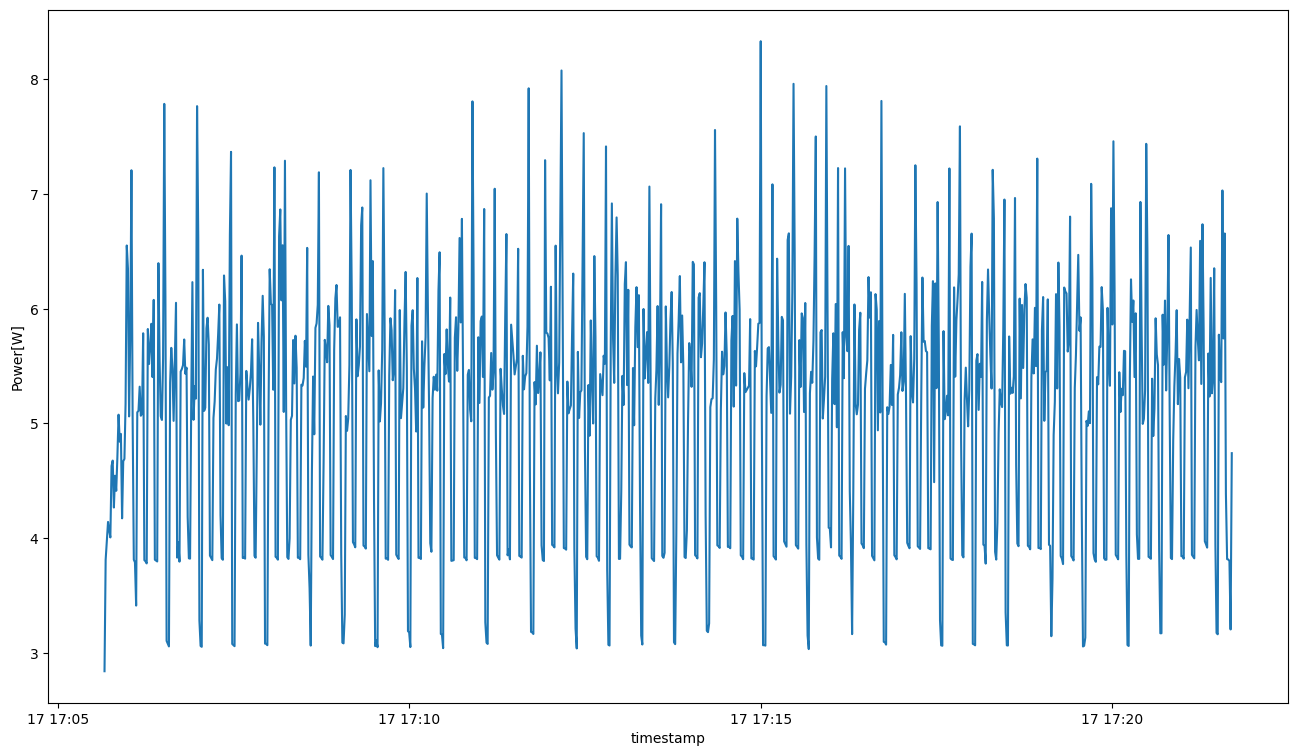

In [38]:
plt.figure(figsize=(16, 9))
sns.lineplot(data=dx21_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

In [39]:
dx21_power.describe()

,Time[S],Volt[V],Current[A],Power[W],dt_hours,energy_Wh
count,963.000000,963.000000,963.000000,963.000000,962.000000,962.000000
mean,481.051506,5.108512,0.996084,5.082774,0.000278,0.001413
std,278.181740,0.004876,0.215800,1.101655,0.000006,0.000307
min,0.000000,5.081600,0.556770,2.839500,0.000269,0.000823
25%,240.500000,5.106800,0.767330,3.914350,0.000271,0.001090
50%,481.100000,5.108900,1.039610,5.308100,0.000283,0.001471
75%,721.600000,5.110500,1.139720,5.822300,0.000283,0.001619
max,962.100000,5.126600,1.633880,8.332700,0.000285,0.002357


## X2.2

passage_time: 05; interval: 3; window: 2

In [84]:
x22_folder_path = '../infra/reports/batch_x22'

### Predict

In [85]:
from pandas import json_normalize
import json

with open(f'{x22_folder_path}/metrics.json') as f:
    x22_data = json.load(f)

load_model_duration = datetime.fromisoformat(x22_data['load_model_final']) - datetime.fromisoformat(x22_data['load_model_start'])
    
rows = []
for animal, v1 in x22_data['animals'].items():
    row = {
        'pid': x22_data['pid'],
        'load_model_start': datetime.fromisoformat(x22_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x22_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],
    }
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx22_metrics_v0 = pd.DataFrame.from_dict(rows)#[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
dx22_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,1,2026-04-17 17:23:20.817550,2026-04-17 17:23:25.051491,2026-04-17 17:23:27.149361,5,2,2026-04-17 17:23:26.053263,2026-04-17 17:23:27.149276
1,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2,2026-04-17 17:23:30.149493,2026-04-17 17:23:34.230082,2026-04-17 17:23:36.324334,5,2,2026-04-17 17:23:35.230087,2026-04-17 17:23:36.324259
2,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,3,2026-04-17 17:23:39.326018,2026-04-17 17:23:43.413946,2026-04-17 17:23:45.510090,5,2,2026-04-17 17:23:44.418656,2026-04-17 17:23:45.510020
3,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,4,2026-04-17 17:23:48.511756,2026-04-17 17:23:52.564145,2026-04-17 17:23:54.659002,5,2,2026-04-17 17:23:53.564108,2026-04-17 17:23:54.658938
4,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,5,2026-04-17 17:23:57.660964,2026-04-17 17:24:01.727721,2026-04-17 17:24:03.836864,5,2,2026-04-17 17:24:02.728530,2026-04-17 17:24:03.836799


In [86]:
dx22_metrics_v0['by_animal_lead_time'] = dx22_metrics_v0['display_time'] - dx22_metrics_v0['first_image_capture_time']
dx22_metrics_v0['by_animal_processing_delay'] = dx22_metrics_v0['weight_prediction_final'] - dx22_metrics_v0['weight_prediction_start']
dx22_metrics_v0['by_animal_latency'] = dx22_metrics_v0['display_time'] - dx22_metrics_v0['last_image_capture_time']

dx22_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,1,2026-04-17 17:23:20.817550,2026-04-17 17:23:25.051491,2026-04-17 17:23:27.149361,5,2,2026-04-17 17:23:26.053263,2026-04-17 17:23:27.149276,0 days 00:00:06.331811,0 days 00:00:01.096013,0 days 00:00:02.097870
1,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2,2026-04-17 17:23:30.149493,2026-04-17 17:23:34.230082,2026-04-17 17:23:36.324334,5,2,2026-04-17 17:23:35.230087,2026-04-17 17:23:36.324259,0 days 00:00:06.174841,0 days 00:00:01.094172,0 days 00:00:02.094252
2,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,3,2026-04-17 17:23:39.326018,2026-04-17 17:23:43.413946,2026-04-17 17:23:45.510090,5,2,2026-04-17 17:23:44.418656,2026-04-17 17:23:45.510020,0 days 00:00:06.184072,0 days 00:00:01.091364,0 days 00:00:02.096144
3,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,4,2026-04-17 17:23:48.511756,2026-04-17 17:23:52.564145,2026-04-17 17:23:54.659002,5,2,2026-04-17 17:23:53.564108,2026-04-17 17:23:54.658938,0 days 00:00:06.147246,0 days 00:00:01.094830,0 days 00:00:02.094857
4,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,5,2026-04-17 17:23:57.660964,2026-04-17 17:24:01.727721,2026-04-17 17:24:03.836864,5,2,2026-04-17 17:24:02.728530,2026-04-17 17:24:03.836799,0 days 00:00:06.175900,0 days 00:00:01.108269,0 days 00:00:02.109143


In [87]:
collect_lead_time = dx22_metrics_v0['display_time'].max() - dx22_metrics_v0['first_image_capture_time'].min()
qtt = len(dx22_metrics_v0['animal'].unique())

dx22_metrics_v0['collect_lead_time'] = collect_lead_time
dx22_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx22_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,1,2026-04-17 17:23:20.817550,2026-04-17 17:23:25.051491,2026-04-17 17:23:27.149361,5,2,2026-04-17 17:23:26.053263,2026-04-17 17:23:27.149276,0 days 00:00:06.331811,0 days 00:00:01.096013,0 days 00:00:02.097870,0 days 00:15:12.280985,394.615262
1,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,2,2026-04-17 17:23:30.149493,2026-04-17 17:23:34.230082,2026-04-17 17:23:36.324334,5,2,2026-04-17 17:23:35.230087,2026-04-17 17:23:36.324259,0 days 00:00:06.174841,0 days 00:00:01.094172,0 days 00:00:02.094252,0 days 00:15:12.280985,394.615262
2,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,3,2026-04-17 17:23:39.326018,2026-04-17 17:23:43.413946,2026-04-17 17:23:45.510090,5,2,2026-04-17 17:23:44.418656,2026-04-17 17:23:45.510020,0 days 00:00:06.184072,0 days 00:00:01.091364,0 days 00:00:02.096144,0 days 00:15:12.280985,394.615262
3,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,4,2026-04-17 17:23:48.511756,2026-04-17 17:23:52.564145,2026-04-17 17:23:54.659002,5,2,2026-04-17 17:23:53.564108,2026-04-17 17:23:54.658938,0 days 00:00:06.147246,0 days 00:00:01.094830,0 days 00:00:02.094857,0 days 00:15:12.280985,394.615262
4,batch_2026-04-17T17:23:13.606892,2026-04-17 17:23:13.607626,2026-04-17 17:23:20.817437,0 days 00:00:07.209811,5,2026-04-17 17:23:57.660964,2026-04-17 17:24:01.727721,2026-04-17 17:24:03.836864,5,2,2026-04-17 17:24:02.728530,2026-04-17 17:24:03.836799,0 days 00:00:06.175900,0 days 00:00:01.108269,0 days 00:00:02.109143,0 days 00:15:12.280985,394.615262


In [88]:
dx22_metrics_v0.describe()

,load_model_dur,total_of_images,suitable_images,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,100,100.0,100.0,100,100,100,100,1.000000e+02
mean,0 days 00:00:07.209811,5.0,2.0,0 days 00:00:06.151042440,0 days 00:00:01.094155640,0 days 00:00:02.093599490,0 days 00:15:12.280985,3.946153e+02
std,0 days 00:00:00,0.0,0.0,0 days 00:00:00.023086494,0 days 00:00:00.006114831,0 days 00:00:00.006548842,0 days 00:00:00,7.426872e-13
min,0 days 00:00:07.209811,5.0,2.0,0 days 00:00:06.122840,0 days 00:00:01.083887,0 days 00:00:02.079102,0 days 00:15:12.280985,3.946153e+02
25%,0 days 00:00:07.209811,5.0,2.0,0 days 00:00:06.138786250,0 days 00:00:01.090165,0 days 00:00:02.088810,0 days 00:15:12.280985,3.946153e+02
50%,0 days 00:00:07.209811,5.0,2.0,0 days 00:00:06.146558,0 days 00:00:01.092441,0 days 00:00:02.092301,0 days 00:15:12.280985,3.946153e+02
75%,0 days 00:00:07.209811,5.0,2.0,0 days 00:00:06.158405500,0 days 00:00:01.098142750,0 days 00:00:02.098106,0 days 00:15:12.280985,3.946153e+02
max,0 days 00:00:07.209811,5.0,2.0,0 days 00:00:06.331811,0 days 00:00:01.114705,0 days 00:00:02.115076,0 days 00:15:12.280985,3.946153e+02


In [89]:
dx22_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:01:49.415564')

In [90]:
total_of_imgs = dx22_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx22_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 500 - Time: 0 days 00:15:12.280985 => FPS:0.5480767529096312


### CPU

In [47]:
dx22_cpu = pd.read_csv(f'{x22_folder_path}/cpu.csv')

dx22_cpu['timestamp'] = dx22_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx22_cpu['cpu_mean']  = dx22_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx22_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-17 17:23:14.609670,3.0,3.0,3.0,94.9,25.975
1,2026-04-17 17:23:15.620245,12.6,37.6,34.7,45.5,32.600
2,2026-04-17 17:23:16.646788,0.0,0.0,0.0,99.0,24.750
3,2026-04-17 17:23:17.647689,0.0,0.0,0.0,61.4,15.350
4,2026-04-17 17:23:18.648134,0.0,0.0,0.0,3.0,0.750


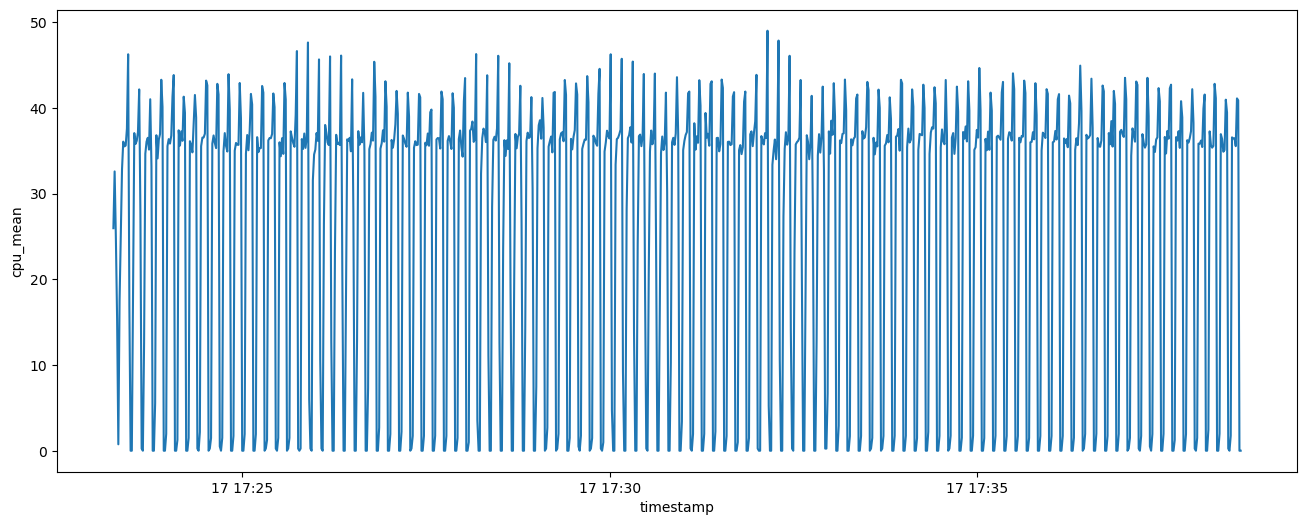

In [48]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx22_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

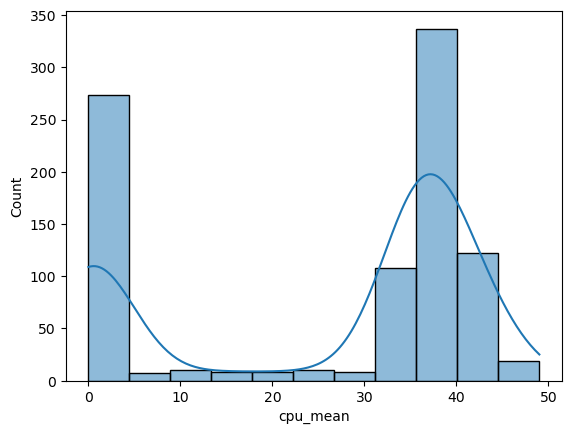

In [49]:
sns.histplot(data=dx22_cpu, x="cpu_mean", kde=True)
plt.show()

In [50]:
dx22_cpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,911.000000,911.000000,911.000000,911.000000,911.000000
mean,24.303293,27.089352,26.418441,24.326015,25.534276
std,21.778822,23.478179,22.739804,21.588562,17.307429
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,1.725000
50%,20.800000,25.500000,25.000000,21.600000,35.800000
75%,37.700000,43.600000,42.400000,38.100000,37.150000
max,91.900000,91.000000,92.100000,100.000000,49.025000


### RAM

In [51]:
dx22_ram = pd.read_csv(f'{x22_folder_path}/mem.csv')
dx22_ram['timestamp'] = dx22_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx22_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-17 17:23:13.607824,17002643456,16381460480,621182976,3.7,15799484416,719716352,184123392,38420480,661766144
1,2026-04-17 17:23:14.609496,17002643456,16340500480,662142976,3.9,15755640832,752795648,185270272,38420480,664305664
2,2026-04-17 17:23:15.625407,17002643456,16269017088,733626368,4.3,15684157440,824918016,185270272,38420480,664305664
3,2026-04-17 17:23:16.636485,17002643456,16231563264,771080192,4.5,15646572544,850165760,185270272,38420480,664436736
4,2026-04-17 17:23:17.636946,17002643456,16090972160,911671296,5.4,15468019712,982319104,223232000,38420480,702726144


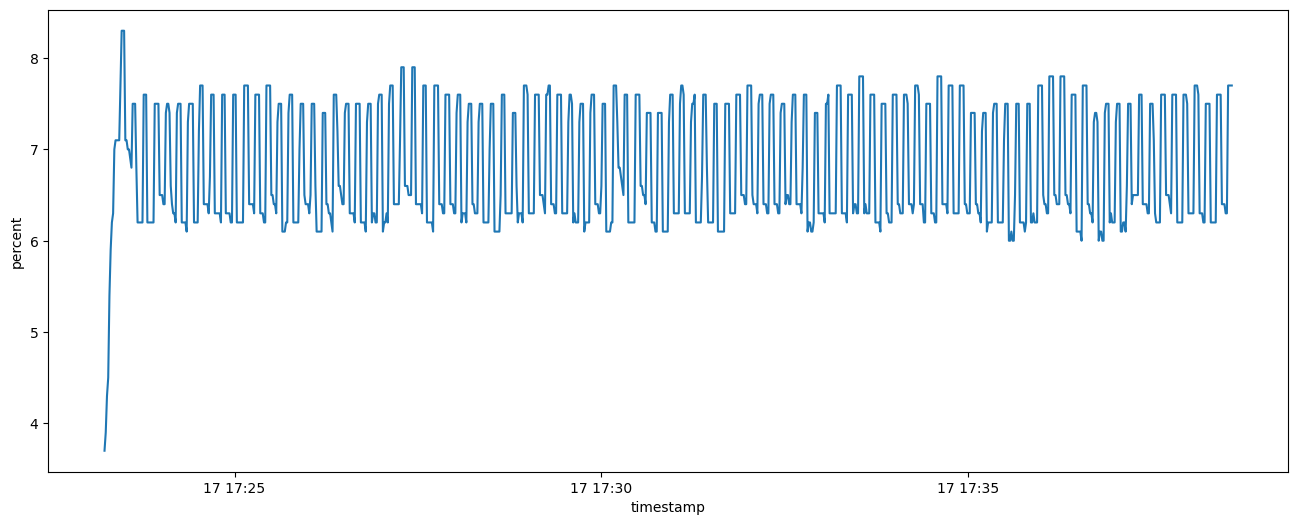

In [52]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx22_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

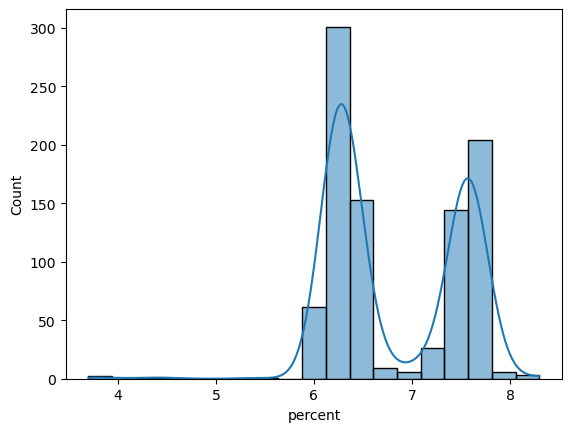

In [53]:
sns.histplot(data=dx22_ram, x="percent", kde=True)
plt.show()

In [54]:
dx22_ram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,9.180000e+02,9.180000e+02,9.180000e+02,918.000000,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02
mean,1.700264e+10,1.584317e+10,1.159473e+09,6.817974,1.509685e+10,1.292058e+09,3.427112e+08,3.851311e+07,8.257464e+08
std,0.000000e+00,1.133172e+08,1.133172e+08,0.666567,1.171029e+08,1.184573e+08,1.121407e+07,1.284345e+05,1.153321e+07
min,1.700264e+10,1.559039e+10,6.211830e+08,3.700000,1.484328e+10,7.197164e+08,1.841234e+08,3.842048e+07,6.617661e+08
25%,1.700264e+10,1.572081e+10,1.063469e+09,6.300000,1.497362e+10,1.198686e+09,3.435233e+08,3.846963e+07,8.266220e+08
50%,1.700264e+10,1.590872e+10,1.093919e+09,6.400000,1.516129e+10,1.201848e+09,3.435233e+08,3.846963e+07,8.266220e+08
75%,1.700264e+10,1.593917e+10,1.281835e+09,7.500000,1.519201e+10,1.431421e+09,3.435397e+08,3.848602e+07,8.266220e+08
max,1.700264e+10,1.638146e+10,1.412252e+09,8.300000,1.579948e+10,1.437270e+09,3.439821e+08,3.892838e+07,8.269332e+08


### Power

In [55]:
dx22_power = pd.read_csv(f'{x22_folder_path}/power.csv')
dx22_power['timestamp'] = dx22_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx22_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-17T17:23:03.372126,0.0,5.1099,0.76189,3.8856,2026-04-17 17:23:03.372126
1,2026-04-17T17:23:04.390572,1.0,5.1045,0.86995,4.4367,2026-04-17 17:23:04.390572
2,2026-04-17T17:23:05.367513,2.0,5.1097,0.79081,4.0331,2026-04-17 17:23:05.367513
3,2026-04-17T17:23:06.387981,3.0,5.1093,0.87220,4.4482,2026-04-17 17:23:06.387981
4,2026-04-17T17:23:07.363427,4.0,5.1089,0.79309,4.0447,2026-04-17 17:23:07.363427


In [56]:
dx22_power = dx22_power.sort_values('timestamp')

# Time difference in hours
dx22_power['dt_hours'] = dx22_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx22_power['energy_Wh'] = dx22_power['Power[W]'] * dx22_power['dt_hours']

# Total energy
total_energy_Wh = dx22_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.2854588055465
Total energy (kWh): 0.0012854588055465


In [57]:
dx22_power.describe()

,Time[S],Volt[V],Current[A],Power[W],dt_hours,energy_Wh
count,936.000000,936.000000,936.000000,936.000000,935.000000,935.000000
mean,467.550962,5.109087,0.969477,4.947751,0.000278,0.001375
std,270.387535,0.004418,0.210624,1.075021,0.000006,0.000300
min,0.000000,5.091400,0.594620,3.038200,0.000269,0.000820
25%,233.750000,5.107600,0.747018,3.811875,0.000271,0.001079
50%,467.600000,5.109500,1.019705,5.205850,0.000283,0.001449
75%,701.350000,5.110800,1.116733,5.700350,0.000283,0.001583
max,935.100000,5.122800,1.504110,7.670900,0.000285,0.002176


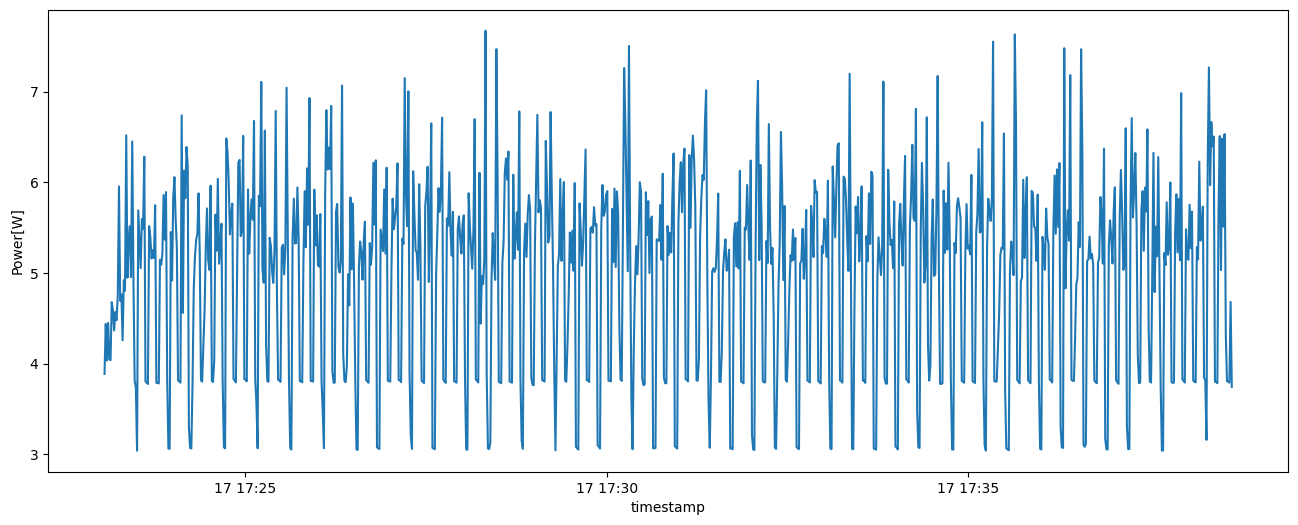

In [58]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx22_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()

## X2.3

passage_time: 05; interval: 3; window: 1

In [59]:
x23_folder_path = '../infra/reports/batch_x23'

### Predict

In [60]:
from pandas import json_normalize
import json

with open(f'{x23_folder_path}/metrics.json') as f:
    x23_data = json.load(f)

load_model_duration = datetime.fromisoformat(x23_data['load_model_final']) - datetime.fromisoformat(x23_data['load_model_start'])
    
rows = []
for animal, v1 in x23_data['animals'].items():
    row = {
        'pid': x23_data['pid'],
        'load_model_start': datetime.fromisoformat(x23_data['load_model_start']),
        'load_model_final': datetime.fromisoformat(x23_data['load_model_final']),
        'load_model_dur': load_model_duration,
        'animal':animal,
        'first_image_capture_time':datetime.fromisoformat(v1['first_image_capture_time']),
        'last_image_capture_time' :datetime.fromisoformat(v1['last_image_capture_time']),
        'display_time' :datetime.fromisoformat(v1['weight_prediction_final']),
        'total_of_images':v1['total_of_images'],
        'suitable_images':v1['suitable_images'],       
    }
    
    for img, v2 in v1['imgs'].items():
        for k, v3 in v2.items():
            row[k] = datetime.fromisoformat(v3)

        rows.append(row)

dx23_metrics_v0 = pd.DataFrame.from_dict(rows)#[['pid','load_model_start','load_model_final','load_model_dur','animal','first_image_capture_time','last_image_capture_time','weight_prediction_start','weight_prediction_final','display_time']]
dx23_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final
0,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,1,2026-04-17 17:40:14.096217,2026-04-17 17:40:18.189555,2026-04-17 17:40:19.991632,5,1,2026-04-17 17:40:19.155883,2026-04-17 17:40:19.991552
1,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2,2026-04-17 17:40:22.991742,2026-04-17 17:40:27.895202,2026-04-17 17:40:29.943751,6,2,2026-04-17 17:40:28.866081,2026-04-17 17:40:29.943682
2,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,3,2026-04-17 17:40:32.944677,2026-04-17 17:40:37.880968,2026-04-17 17:40:39.704239,6,1,2026-04-17 17:40:38.869534,2026-04-17 17:40:39.704174
3,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,4,2026-04-17 17:40:42.705932,2026-04-17 17:40:47.622870,2026-04-17 17:40:49.681409,6,2,2026-04-17 17:40:48.603484,2026-04-17 17:40:49.681346
4,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,5,2026-04-17 17:40:52.683097,2026-04-17 17:40:57.636133,2026-04-17 17:40:59.681285,6,2,2026-04-17 17:40:58.604857,2026-04-17 17:40:59.681222


In [61]:
dx23_metrics_v0['by_animal_lead_time'] = dx23_metrics_v0['display_time'] - dx23_metrics_v0['first_image_capture_time']
dx23_metrics_v0['by_animal_processing_delay'] = dx23_metrics_v0['weight_prediction_final'] - dx23_metrics_v0['weight_prediction_start']
dx23_metrics_v0['by_animal_latency'] = dx23_metrics_v0['display_time'] - dx23_metrics_v0['last_image_capture_time']

dx23_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency
0,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,1,2026-04-17 17:40:14.096217,2026-04-17 17:40:18.189555,2026-04-17 17:40:19.991632,5,1,2026-04-17 17:40:19.155883,2026-04-17 17:40:19.991552,0 days 00:00:05.895415,0 days 00:00:00.835669,0 days 00:00:01.802077
1,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2,2026-04-17 17:40:22.991742,2026-04-17 17:40:27.895202,2026-04-17 17:40:29.943751,6,2,2026-04-17 17:40:28.866081,2026-04-17 17:40:29.943682,0 days 00:00:06.952009,0 days 00:00:01.077601,0 days 00:00:02.048549
2,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,3,2026-04-17 17:40:32.944677,2026-04-17 17:40:37.880968,2026-04-17 17:40:39.704239,6,1,2026-04-17 17:40:38.869534,2026-04-17 17:40:39.704174,0 days 00:00:06.759562,0 days 00:00:00.834640,0 days 00:00:01.823271
3,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,4,2026-04-17 17:40:42.705932,2026-04-17 17:40:47.622870,2026-04-17 17:40:49.681409,6,2,2026-04-17 17:40:48.603484,2026-04-17 17:40:49.681346,0 days 00:00:06.975477,0 days 00:00:01.077862,0 days 00:00:02.058539
4,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,5,2026-04-17 17:40:52.683097,2026-04-17 17:40:57.636133,2026-04-17 17:40:59.681285,6,2,2026-04-17 17:40:58.604857,2026-04-17 17:40:59.681222,0 days 00:00:06.998188,0 days 00:00:01.076365,0 days 00:00:02.045152


In [62]:
collect_lead_time = dx23_metrics_v0['display_time'].max() - dx23_metrics_v0['first_image_capture_time'].min()
qtt = len(dx23_metrics_v0['animal'].unique())

dx23_metrics_v0['collect_lead_time'] = collect_lead_time
dx23_metrics_v0['mean_throughput'] = qtt / (collect_lead_time.total_seconds() / 60 / 60) # hour

dx23_metrics_v0.head()

,pid,load_model_start,load_model_final,load_model_dur,animal,first_image_capture_time,last_image_capture_time,display_time,total_of_images,suitable_images,weight_prediction_start,weight_prediction_final,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
0,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,1,2026-04-17 17:40:14.096217,2026-04-17 17:40:18.189555,2026-04-17 17:40:19.991632,5,1,2026-04-17 17:40:19.155883,2026-04-17 17:40:19.991552,0 days 00:00:05.895415,0 days 00:00:00.835669,0 days 00:00:01.802077,0 days 00:16:28.097418,364.336546
1,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,2,2026-04-17 17:40:22.991742,2026-04-17 17:40:27.895202,2026-04-17 17:40:29.943751,6,2,2026-04-17 17:40:28.866081,2026-04-17 17:40:29.943682,0 days 00:00:06.952009,0 days 00:00:01.077601,0 days 00:00:02.048549,0 days 00:16:28.097418,364.336546
2,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,3,2026-04-17 17:40:32.944677,2026-04-17 17:40:37.880968,2026-04-17 17:40:39.704239,6,1,2026-04-17 17:40:38.869534,2026-04-17 17:40:39.704174,0 days 00:00:06.759562,0 days 00:00:00.834640,0 days 00:00:01.823271,0 days 00:16:28.097418,364.336546
3,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,4,2026-04-17 17:40:42.705932,2026-04-17 17:40:47.622870,2026-04-17 17:40:49.681409,6,2,2026-04-17 17:40:48.603484,2026-04-17 17:40:49.681346,0 days 00:00:06.975477,0 days 00:00:01.077862,0 days 00:00:02.058539,0 days 00:16:28.097418,364.336546
4,batch_2026-04-17T17:40:07.128032,2026-04-17 17:40:07.128735,2026-04-17 17:40:14.096098,0 days 00:00:06.967363,5,2026-04-17 17:40:52.683097,2026-04-17 17:40:57.636133,2026-04-17 17:40:59.681285,6,2,2026-04-17 17:40:58.604857,2026-04-17 17:40:59.681222,0 days 00:00:06.998188,0 days 00:00:01.076365,0 days 00:00:02.045152,0 days 00:16:28.097418,364.336546


In [63]:
dx23_metrics_v0.describe()

,load_model_dur,total_of_images,suitable_images,by_animal_lead_time,by_animal_processing_delay,by_animal_latency,collect_lead_time,mean_throughput
count,100,100.00,100.000000,100,100,100,100,1.000000e+02
mean,0 days 00:00:06.967363,5.99,1.760000,0 days 00:00:06.909305790,0 days 00:00:01.019039250,0 days 00:00:01.995511930,0 days 00:16:28.097418,3.643365e+02
std,0 days 00:00:00,0.10,0.429235,0 days 00:00:00.139444473,0 days 00:00:00.104033509,0 days 00:00:00.100743214,0 days 00:00:00,5.712979e-14
min,0 days 00:00:06.967363,5.00,1.000000,0 days 00:00:05.895415,0 days 00:00:00.831709,0 days 00:00:01.802077,0 days 00:16:28.097418,3.643365e+02
25%,0 days 00:00:06.967363,6.00,2.000000,0 days 00:00:06.940671750,0 days 00:00:01.065616,0 days 00:00:02.036826750,0 days 00:16:28.097418,3.643365e+02
50%,0 days 00:00:06.967363,6.00,2.000000,0 days 00:00:06.960227500,0 days 00:00:01.072188500,0 days 00:00:02.047566500,0 days 00:16:28.097418,3.643365e+02
75%,0 days 00:00:06.967363,6.00,2.000000,0 days 00:00:06.976052750,0 days 00:00:01.081017250,0 days 00:00:02.053530,0 days 00:16:28.097418,3.643365e+02
max,0 days 00:00:06.967363,6.00,2.000000,0 days 00:00:07.013703,0 days 00:00:01.097816,0 days 00:00:02.088859,0 days 00:16:28.097418,3.643365e+02


In [64]:
dx23_metrics_v0['by_animal_processing_delay'].sum()

Timedelta('0 days 00:01:41.903925')

In [65]:
total_of_imgs = dx23_metrics_v0['total_of_images'].sum()
total_time = pd.to_timedelta(dx23_metrics_v0['collect_lead_time'].unique()[0])

print(f'Imgs: {total_of_imgs} - Time: {total_time} => FPS:{total_of_imgs / total_time.total_seconds()}')

Imgs: 599 - Time: 0 days 00:16:28.097418 => FPS:0.606215530056167


### CPU

In [66]:
dx23_cpu = pd.read_csv(f'{x23_folder_path}/cpu.csv')

dx23_cpu['timestamp'] = dx23_cpu['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx23_cpu['cpu_mean']  = dx23_cpu[['cpu_core_0', 'cpu_core_1', 'cpu_core_2', 'cpu_core_3']].mean(axis=1)

dx23_cpu.head()

,timestamp,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
0,2026-04-17 17:40:08.129732,1.0,3.0,95.0,2.0,25.250
1,2026-04-17 17:40:09.145478,11.0,40.8,63.0,10.0,31.200
2,2026-04-17 17:40:10.319013,0.9,81.2,17.5,0.9,25.125
3,2026-04-17 17:40:11.319525,1.0,0.0,37.6,0.0,9.650
4,2026-04-17 17:40:12.319928,0.0,0.0,4.0,1.0,1.250


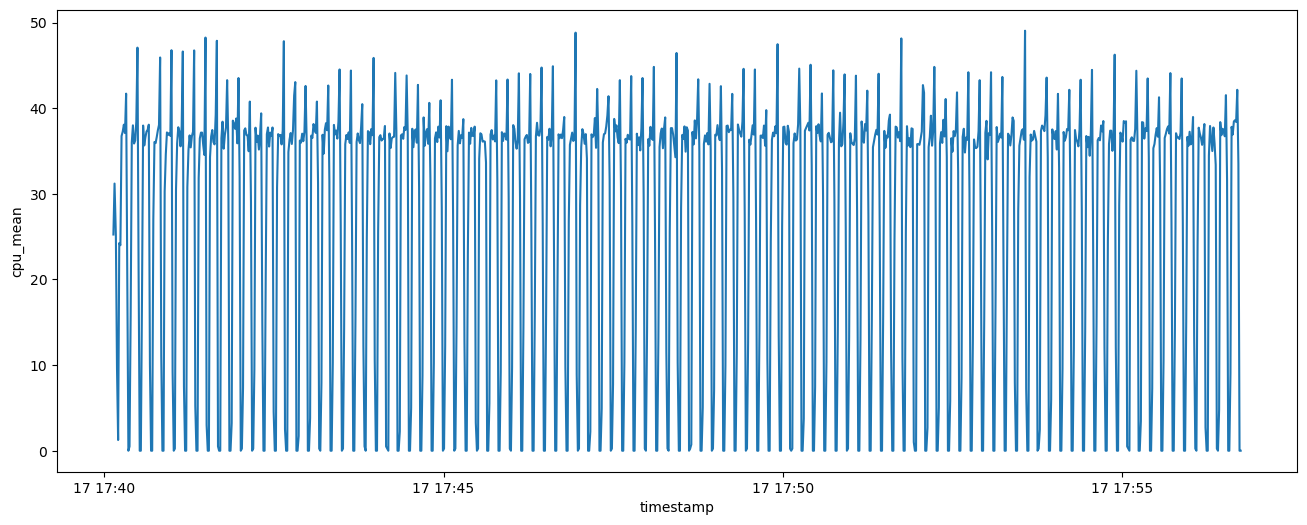

In [67]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx23_cpu.sort_values(by='timestamp'), x="timestamp", y="cpu_mean")
plt.show()

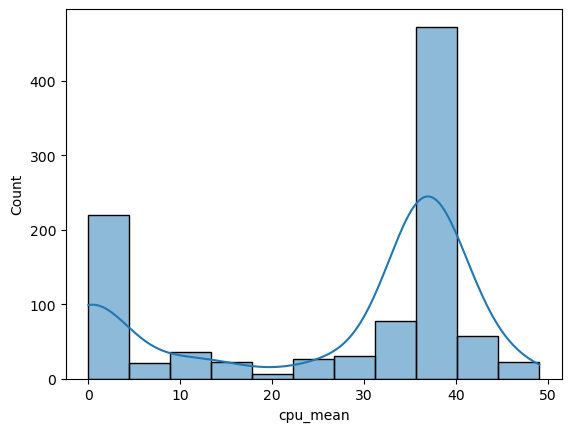

In [68]:
sns.histplot(data=dx23_cpu, x="cpu_mean", kde=True)
plt.show()

In [69]:
dx23_cpu.describe()

,cpu_core_0,cpu_core_1,cpu_core_2,cpu_core_3,cpu_mean
count,994.000000,994.000000,994.000000,994.000000,994.000000
mean,23.690040,28.871932,29.372535,24.061066,26.498893
std,19.355075,23.076808,24.281167,19.351144,16.035689
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.100000,6.100000,6.000000,6.025000,9.743750
50%,20.900000,26.250000,24.600000,22.000000,36.087500
75%,34.700000,44.600000,45.875000,35.375000,37.300000
max,90.000000,91.900000,97.000000,88.000000,49.050000


### RAM

In [70]:
dx23_ram = pd.read_csv(f'{x23_folder_path}/mem.csv')
dx23_ram['timestamp'] = dx23_ram['timestamp'].apply(lambda x: datetime.fromisoformat(x))
dx23_ram.head()

,timestamp,total,available,used,percent,free,active,inactive,buffers,cached
0,2026-04-17 17:40:07.128923,17002643456,16404578304,598065152,3.5,15822569472,720044032,184516608,38420480,661749760
1,2026-04-17 17:40:08.129821,17002643456,16333815808,668827648,3.9,15748857856,756531200,185319424,38436864,664272896
2,2026-04-17 17:40:09.145592,17002643456,16282173440,720470016,4.2,15697215488,824082432,185319424,38436864,664272896
3,2026-04-17 17:40:10.166128,17002643456,16220372992,782270464,4.6,15635283968,862765056,185319424,38436864,664403968
4,2026-04-17 17:40:11.166486,17002643456,16079405056,923238400,5.4,15447244800,991363072,232390656,38436864,711868416


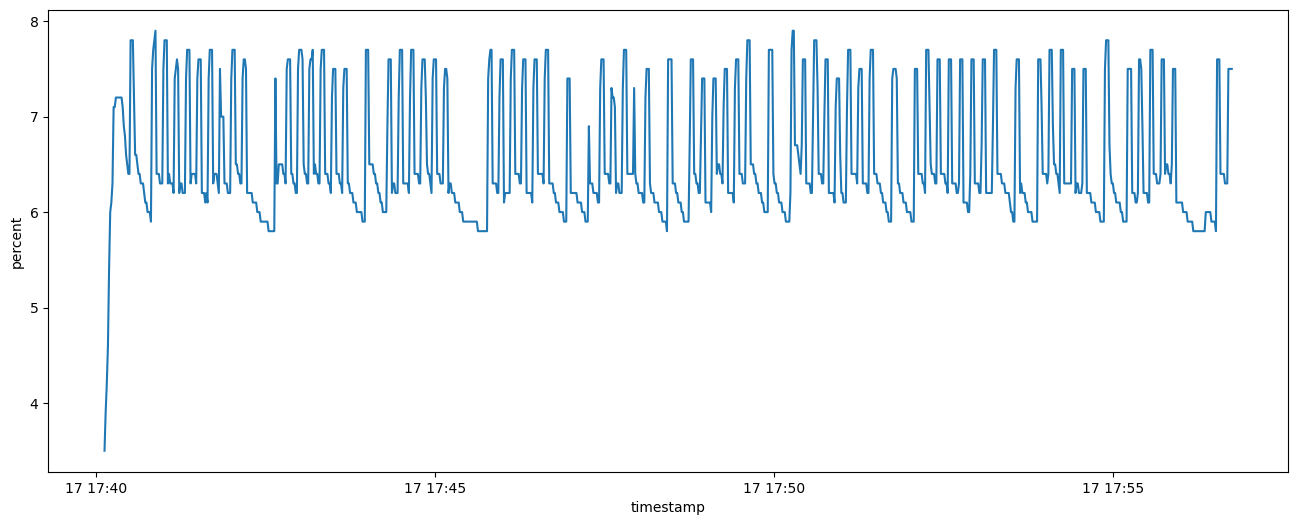

In [71]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx23_ram.sort_values(by='timestamp'), x="timestamp", y="percent")
plt.show()

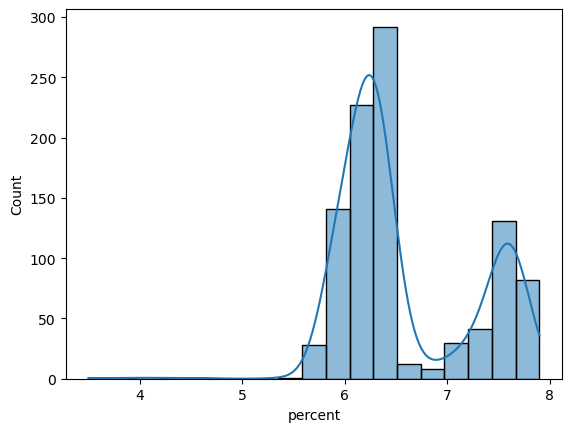

In [72]:
sns.histplot(data=dx23_ram, x="percent", kde=True)
plt.show()

In [73]:
dx23_ram.describe()

,total,available,used,percent,free,active,inactive,buffers,cached
count,9.970000e+02,9.970000e+02,9.970000e+02,997.00000,9.970000e+02,9.970000e+02,9.970000e+02,9.970000e+02,9.970000e+02
mean,1.700264e+10,1.588490e+10,1.117741e+09,6.57342,1.513834e+10,1.261533e+09,3.428880e+08,3.856470e+07,8.258285e+08
std,0.000000e+00,1.109866e+08,1.109866e+08,0.65443,1.141987e+08,1.039854e+08,1.063222e+07,1.534324e+05,1.093728e+07
min,1.700264e+10,1.565575e+10,5.980652e+08,3.50000,1.490849e+10,7.200440e+08,1.845166e+08,3.842048e+07,6.617498e+08
25%,1.700264e+10,1.576393e+10,1.043513e+09,6.10000,1.501664e+10,1.202749e+09,3.435889e+08,3.850240e+07,8.266056e+08
50%,1.700264e+10,1.592964e+10,1.073005e+09,6.30000,1.518233e+10,1.203716e+09,3.436052e+08,3.851878e+07,8.266056e+08
75%,1.700264e+10,1.595913e+10,1.238712e+09,7.30000,1.521182e+10,1.388642e+09,3.436052e+08,3.851878e+07,8.266056e+08
max,1.700264e+10,1.640458e+10,1.346896e+09,7.90000,1.582257e+10,1.437745e+09,3.440476e+08,3.896115e+07,8.268841e+08


### Power

In [74]:
dx23_power = pd.read_csv(f'{x23_folder_path}/power.csv')
dx23_power['timestamp'] = dx23_power['Datetime'].apply(lambda x: datetime.fromisoformat(x))
dx23_power.head()

,Datetime,Time[S],Volt[V],Current[A],Power[W],timestamp
0,2026-04-17T17:39:56.343834,0.0,5.1097,0.71063,3.6242,2026-04-17 17:39:56.343834
1,2026-04-17T17:39:57.315169,1.0,5.1097,0.71011,3.6215,2026-04-17 17:39:57.315169
2,2026-04-17T17:39:58.331580,2.0,5.1100,0.82029,4.1916,2026-04-17 17:39:58.331580
3,2026-04-17T17:39:59.347140,3.0,5.1098,0.79178,4.0380,2026-04-17 17:39:59.347140
4,2026-04-17T17:40:00.317420,4.0,5.1098,0.86316,4.4021,2026-04-17 17:40:00.317420


In [75]:
dx23_power = dx23_power.sort_values('timestamp')

# Time difference in hours
dx23_power['dt_hours'] = dx23_power['timestamp'].diff().dt.total_seconds() / 3600

# Energy (Wh)
dx23_power['energy_Wh'] = dx23_power['Power[W]'] * dx23_power['dt_hours']

# Total energy
total_energy_Wh = dx23_power['energy_Wh'].sum()

print("Total energy (Wh):", total_energy_Wh)
print("Total energy (kWh):", total_energy_Wh / 1000)

Total energy (Wh): 1.4217573599010276
Total energy (kWh): 0.0014217573599010277


In [76]:
dx23_power.describe()

,Time[S],Volt[V],Current[A],Power[W],dt_hours,energy_Wh
count,1015.000000,1015.000000,1015.000000,1015.000000,1014.000000,1014.000000
mean,507.057537,5.109641,0.988373,5.045314,0.000278,0.001402
std,293.191903,0.004281,0.188822,0.963742,0.000006,0.000270
min,0.000000,5.092200,0.599710,3.064500,0.000269,0.000827
25%,253.500000,5.108450,0.752070,3.841350,0.000271,0.001085
50%,507.100000,5.110000,1.024830,5.231200,0.000283,0.001461
75%,760.600000,5.111300,1.125370,5.748000,0.000283,0.001586
max,1014.100000,5.126100,1.635720,8.342100,0.000285,0.002261


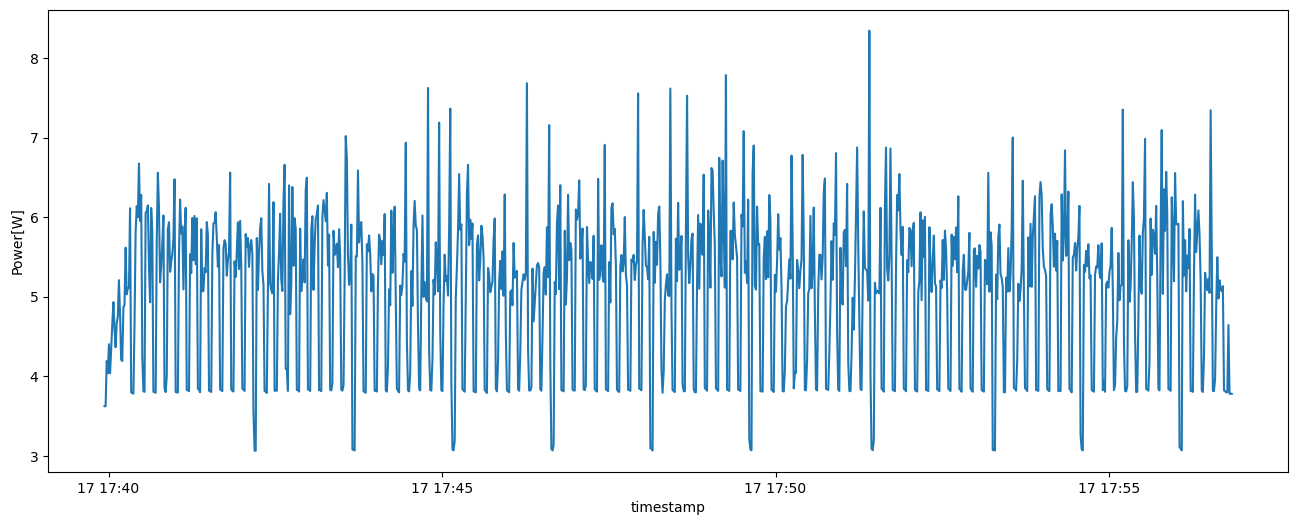

In [77]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=dx23_power.sort_values(by='timestamp'), x="timestamp", y="Power[W]")
plt.show()